In [1]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


Train shape: (3497, 39)
Test shape: (875, 39)
✅ Model training completed.

Confusion Matrix:
[[584   0]
 [  0 291]]


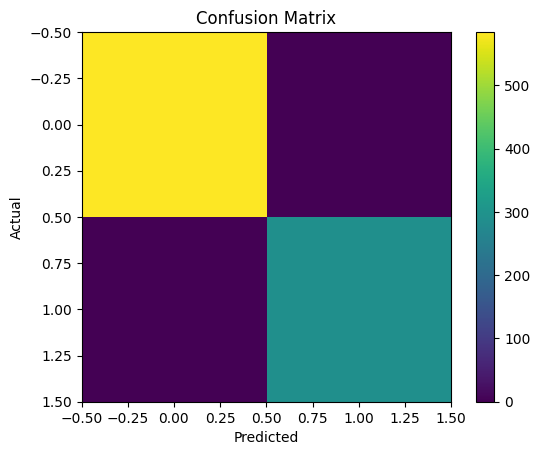


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       584
           1       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875


ROC-AUC Score: 1.0


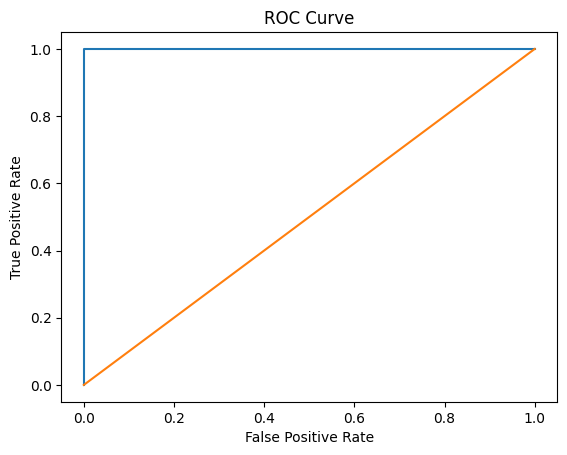

✅ Model saved in models/logistic_regression.pkl


In [2]:

# ============================================================
# LOAD PROCESSED DATA
# ============================================================

X_train = pd.read_csv("data/train_test/X_train.csv")
X_test = pd.read_csv("data/train_test/X_test.csv")

y_train = pd.read_csv("data/train_test/y_train.csv")["Churn"]
y_test = pd.read_csv("data/train_test/y_test.csv")["Churn"]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ============================================================
# TRAIN BASELINE MODEL (LOGISTIC REGRESSION)
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # handles class imbalance
    random_state=42
)

model.fit(X_train, y_train)

print("✅ Model training completed.")

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ============================================================
# ROC-AUC SCORE
# ============================================================

roc_auc = roc_auc_score(y_test, y_proba)
print("\nROC-AUC Score:", roc_auc)

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================

joblib.dump(model, "models/logistic_regression.pkl")
print("✅ Model saved in models/logistic_regression.pkl")